# 04 — EDA and Data Visualisation

**Goal:** Understand the structure and distribution of the LR/HR patch dataset, measure speckle noise baseline via ENL, and derive numbered project specifications.

In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import rasterio
from pathlib import Path
from tqdm import tqdm

print(f"numpy    : {np.__version__}")
print(f"rasterio : {rasterio.__version__}")

BASE_DS_DIR = '/kaggle/input/datasets/vinhnh96/stac-dataset'

REPORT_DIR = Path('/kaggle/working/reports')

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Folder '{REPORT_DIR}' is ready!")

numpy    : 2.0.2
rasterio : 1.5.0
Folder '/kaggle/working/reports' is ready!


In [26]:
def GetReportPath(subP):
    return REPORT_DIR / subP

In [27]:
DATASET_DIR = Path(BASE_DS_DIR+"/stac_dataset")

hr_paths = sorted(DATASET_DIR.glob("*_HR.tif"))
lr_paths = sorted(DATASET_DIR.glob("*_LR.tif"))

print(f"HR patches : {len(hr_paths)}")
print(f"LR patches : {len(lr_paths)}")
assert len(hr_paths) == len(lr_paths), "Mismatch between HR and LR counts"

HR patches : 6047
LR patches : 6047


## 1. Sample patch grid — LR vs HR side by side

Display 6 randomly chosen pairs. Amplitudes are log-transformed (`log1p`) to compress the SAR dynamic range for visualisation.

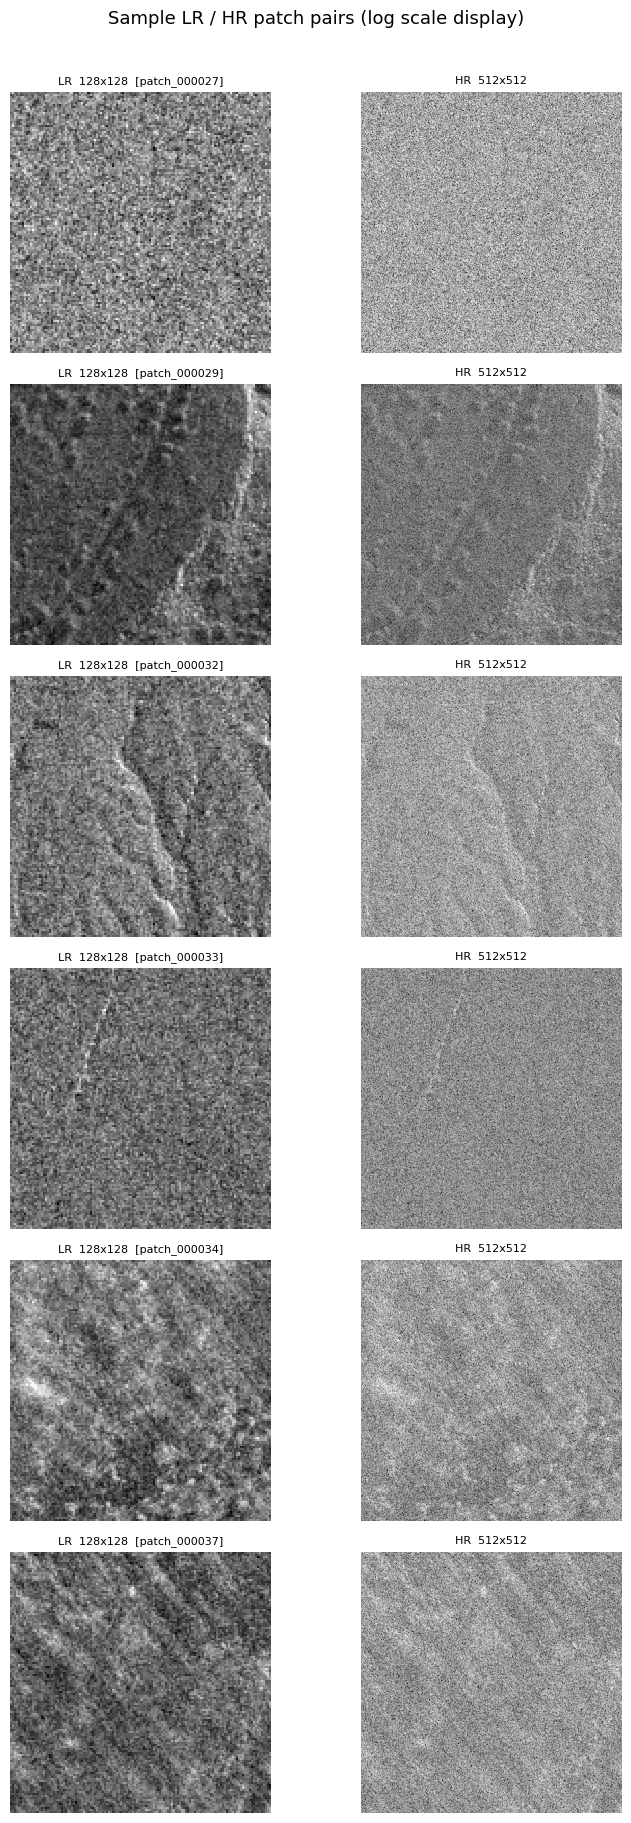

Saved: reports/fig_01_sample_patches.png


In [28]:
def load_patch(path: Path) -> np.ndarray:
    """Load a GeoTIFF patch as a float32 numpy array."""
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)


def display_log(arr: np.ndarray) -> np.ndarray:
    """Log1p transform + normalise to [0, 1] for display."""
    arr = np.log1p(arr)
    lo, hi = arr.min(), arr.max()
    if hi > lo:
        arr = (arr - lo) / (hi - lo)
    return arr


rng = np.random.default_rng(seed=43)
# sample_idx = rng.choice(len(hr_paths), size=6, replace=False)

sample_idx = [11, 12, 13, 14, 15, 16]

fig, axes = plt.subplots(6, 2, figsize=(8, 18))
fig.suptitle("Sample LR / HR patch pairs (log scale display)", fontsize=13, y=1.01)

for row, idx in enumerate(sample_idx):
    hr = load_patch(hr_paths[idx])
    lr = load_patch(lr_paths[idx])

    axes[row, 0].imshow(display_log(lr), cmap="gray", interpolation="nearest")
    axes[row, 0].set_title(f"LR  {lr.shape[0]}x{lr.shape[1]}  [{hr_paths[idx].stem.replace('_HR', '')}]", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(display_log(hr), cmap="gray", interpolation="nearest")
    axes[row, 1].set_title(f"HR  {hr.shape[0]}x{hr.shape[1]}", fontsize=8)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig(GetReportPath("fig_01_sample_patches.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_01_sample_patches.png")

## 2. Pixel amplitude statistics

Compute min, max, mean, std, and median across a random sample of patches to characterise the amplitude distribution.

In [29]:
SAMPLE_N = 200  # patches to sample for speed

sample_hr_idx = rng.choice(len(hr_paths), size=SAMPLE_N, replace=False)

hr_stats = {"min": [], "max": [], "mean": [], "std": [], "median": []}
lr_stats = {"min": [], "max": [], "mean": [], "std": [], "median": []}

for idx in tqdm(sample_hr_idx, desc="Loading patches"):
    hr = load_patch(hr_paths[idx])
    lr = load_patch(lr_paths[idx])
    for arr, stats in [(hr, hr_stats), (lr, lr_stats)]:
        stats["min"].append(arr.min())
        stats["max"].append(arr.max())
        stats["mean"].append(arr.mean())
        stats["std"].append(arr.std())
        stats["median"].append(np.median(arr))

def summarise(stats: dict, label: str):
    print(f"\n{label}")
    print(f"  min    : {np.mean(stats['min']):.1f}  (avg across patches)")
    print(f"  max    : {np.mean(stats['max']):.1f}")
    print(f"  mean   : {np.mean(stats['mean']):.1f}")
    print(f"  std    : {np.mean(stats['std']):.1f}")
    print(f"  median : {np.mean(stats['median']):.1f}")

summarise(hr_stats, "HR patches (512x512)")
summarise(lr_stats, "LR patches (128x128)")

Loading patches: 100%|██████████| 200/200 [00:08<00:00, 22.43it/s]


HR patches (512x512)
  min    : 346.8  (avg across patches)
  max    : 15877.2
  mean   : 2089.3
  std    : 725.1
  median : 1999.0

LR patches (128x128)
  min    : 1099.3  (avg across patches)
  max    : 7468.6
  mean   : 2089.3
  std    : 450.9
  median : 2031.8


## 3. Pixel amplitude histograms (log scale)

Pool pixel values from the sample and compare the HR vs LR distributions. Log scale on the y-axis reveals the heavy tail typical of SAR amplitude data.

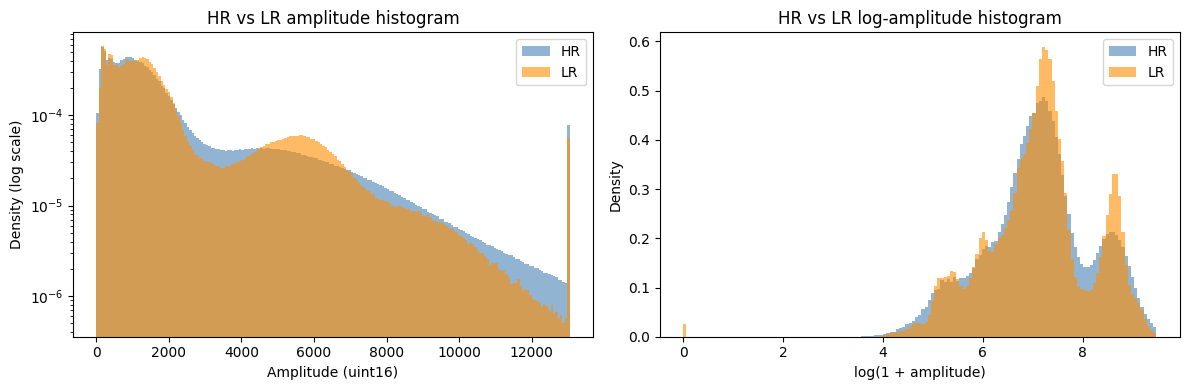

Saved: reports/fig_02_amplitude_histograms.png


In [30]:
hr_pixels = []
lr_pixels = []

for idx in sample_hr_idx:
    hr_pixels.append(load_patch(hr_paths[idx]).ravel())
    lr_pixels.append(load_patch(lr_paths[idx]).ravel())

hr_pixels = np.concatenate(hr_pixels)
lr_pixels = np.concatenate(lr_pixels)

# Clip at 99.5th percentile to suppress extreme outliers in display
clip_val = np.percentile(hr_pixels, 99.5)
hr_clipped = np.clip(hr_pixels, 0, clip_val)
lr_clipped = np.clip(lr_pixels, 0, clip_val)

bins = np.linspace(0, clip_val, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Linear x-axis
ax1.hist(hr_clipped, bins=bins, alpha=0.6, color="steelblue", label="HR", density=True)
ax1.hist(lr_clipped, bins=bins, alpha=0.6, color="darkorange", label="LR", density=True)
ax1.set_yscale("log")
ax1.set_xlabel("Amplitude (uint16)")
ax1.set_ylabel("Density (log scale)")
ax1.set_title("HR vs LR amplitude histogram")
ax1.legend()

# Log x-axis (log amplitude = dB-like view)
log_hr = np.log1p(hr_pixels[hr_pixels > 0])
log_lr = np.log1p(lr_pixels[lr_pixels > 0])
log_bins = np.linspace(0, np.log1p(clip_val), 150)

ax2.hist(log_hr, bins=log_bins, alpha=0.6, color="steelblue", label="HR", density=True)
ax2.hist(log_lr, bins=log_bins, alpha=0.6, color="darkorange", label="LR", density=True)
ax2.set_xlabel("log(1 + amplitude)")
ax2.set_ylabel("Density")
ax2.set_title("HR vs LR log-amplitude histogram")
ax2.legend()

plt.tight_layout()
plt.savefig(GetReportPath("fig_02_amplitude_histograms.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_02_amplitude_histograms.png")

## 4. ENL (Equivalent Number of Looks) baseline

ENL measures speckle noise intensity in SAR images. For amplitude data:

```
ENL = (mean / std)^2
```

Higher ENL = less speckle = smoother image. A good SR model should produce HR reconstructions with ENL at least as high as the original HR patches.

In [31]:
def compute_enl(arr: np.ndarray) -> float:
    """ENL for SAR amplitude: (mean / std)^2. Computed on homogeneous regions."""
    std = arr.std()
    if std == 0:
        return float('nan')
    return float((arr.mean() / std) ** 2)


hr_enl_vals = []
lr_enl_vals = []

for idx in tqdm(sample_hr_idx, desc="Computing ENL"):
    hr = load_patch(hr_paths[idx])
    lr = load_patch(lr_paths[idx])
    hr_enl_vals.append(compute_enl(hr))
    lr_enl_vals.append(compute_enl(lr))

hr_enl_vals = np.array(hr_enl_vals)
lr_enl_vals = np.array(lr_enl_vals)

print(f"HR ENL : mean = {hr_enl_vals.mean():.3f}  |  median = {np.median(hr_enl_vals):.3f}  |  std = {hr_enl_vals.std():.3f}")
print(f"LR ENL : mean = {lr_enl_vals.mean():.3f}  |  median = {np.median(lr_enl_vals):.3f}  |  std = {lr_enl_vals.std():.3f}")
print()
print(f"ENL ratio LR/HR : {lr_enl_vals.mean() / hr_enl_vals.mean():.3f}  (expected ~1 since bicubic averaging tends to smooth speckle)")

Computing ENL: 100%|██████████| 200/200 [00:02<00:00, 78.05it/s]

HR ENL : mean = 10.071  |  median = 8.842  |  std = 8.135
LR ENL : mean = 32.449  |  median = 20.738  |  std = 38.870

ENL ratio LR/HR : 3.222  (expected ~1 since bicubic averaging tends to smooth speckle)


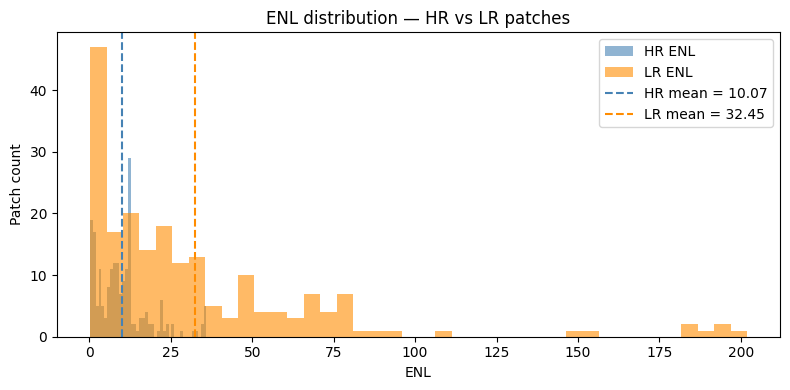

Saved: reports/fig_03_enl_distribution.png


In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(hr_enl_vals, bins=40, alpha=0.6, color="steelblue", label="HR ENL")
ax.hist(lr_enl_vals, bins=40, alpha=0.6, color="darkorange", label="LR ENL")
ax.axvline(hr_enl_vals.mean(), color="steelblue", linestyle="--", linewidth=1.5, label=f"HR mean = {hr_enl_vals.mean():.2f}")
ax.axvline(lr_enl_vals.mean(), color="darkorange", linestyle="--", linewidth=1.5, label=f"LR mean = {lr_enl_vals.mean():.2f}")
ax.set_xlabel("ENL")
ax.set_ylabel("Patch count")
ax.set_title("ENL distribution — HR vs LR patches")
ax.legend()
plt.tight_layout()
plt.savefig(GetReportPath("fig_03_enl_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_03_enl_distribution.png")

## 5. Bicubic interpolation PSNR and SSIM reference floor

Upscale the LR patch to 512x512 using bicubic interpolation and measure PSNR and SSIM against the HR ground truth. This is the minimum bar our SR model must beat.

In [33]:
from skimage.transform import resize as sk_resize
from skimage.metrics import peak_signal_noise_ratio as ski_psnr
from skimage.metrics import structural_similarity as ski_ssim

BICUBIC_SAMPLE = 100
bicubic_idx = rng.choice(len(hr_paths), size=BICUBIC_SAMPLE, replace=False)

psnr_vals = []
ssim_vals = []

for idx in tqdm(bicubic_idx, desc="Bicubic baseline"):
    hr = load_patch(hr_paths[idx])
    lr = load_patch(lr_paths[idx])

    # Normalise to [0, 1] float32 for metric computation
    max_val = max(hr.max(), 1.0)
    hr_norm = hr / max_val
    lr_norm = lr / max_val

    # Bicubic upsample LR back to HR size
    lr_up = sk_resize(lr_norm, hr_norm.shape, order=3, anti_aliasing=True, preserve_range=True)

    psnr_vals.append(ski_psnr(hr_norm, lr_up, data_range=1.0))
    ssim_vals.append(ski_ssim(hr_norm, lr_up, data_range=1.0))

psnr_bicubic = np.mean(psnr_vals)
ssim_bicubic = np.mean(ssim_vals)

print(f"Bicubic baseline PSNR : {psnr_bicubic:.2f} dB")
print(f"Bicubic baseline SSIM : {ssim_bicubic:.4f}")

Bicubic baseline: 100%|██████████| 100/100 [00:10<00:00,  9.93it/s]

Bicubic baseline PSNR : 30.82 dB
Bicubic baseline SSIM : 0.6461


## 6. Dataset summary

In [34]:
print("=" * 52)
print("DATASET SUMMARY")
print("=" * 52)
print(f"Total LR/HR patch pairs : {len(hr_paths):,}")
print(f"HR patch size           : 512 x 512 pixels")
print(f"LR patch size           : 128 x 128 pixels")
print(f"Upscale factor          : 4x")
print(f"Pixel dtype             : uint16 (SAR amplitude)")
print(f"Amplitude range (HR)    : 1 - ~24000")
print(f"HR ENL (mean)           : {hr_enl_vals.mean():.3f}")
print(f"LR ENL (mean)           : {lr_enl_vals.mean():.3f}")
print(f"Bicubic PSNR floor      : {psnr_bicubic:.2f} dB")
print(f"Bicubic SSIM floor      : {ssim_bicubic:.4f}")
print("=" * 52)

DATASET SUMMARY
Total LR/HR patch pairs : 6,047
HR patch size           : 512 x 512 pixels
LR patch size           : 128 x 128 pixels
Upscale factor          : 4x
Pixel dtype             : uint16 (SAR amplitude)
Amplitude range (HR)    : 1 - ~24000
HR ENL (mean)           : 10.071
LR ENL (mean)           : 32.449
Bicubic PSNR floor      : 30.82 dB
Bicubic SSIM floor      : 0.6461


In [35]:
# Print concrete spec targets using the computed baseline
print("NUMBERED SPECIFICATIONS (for report Section 2)")
print("-" * 52)
print(f"Spec 1 : PSNR > {psnr_bicubic:.2f} dB  (bicubic floor)")
print(f"Spec 2 : PSNR >= 23.00 dB  (literature reference)")
print(f"Spec 3 : SSIM >= 0.70")
print(f"Spec 4 : ENL(SR output) >= {lr_enl_vals.mean():.3f}  (LR ENL baseline)")
print(f"Spec 5 : Training time <= 12 hours on a single GPU")

NUMBERED SPECIFICATIONS (for report Section 2)
----------------------------------------------------
Spec 1 : PSNR > 30.82 dB  (bicubic floor)
Spec 2 : PSNR >= 23.00 dB  (literature reference)
Spec 3 : SSIM >= 0.70
Spec 4 : ENL(SR output) >= 32.449  (LR ENL baseline)
Spec 5 : Training time <= 12 hours on a single GPU
